- Problem Statement


- The telecom company is experiencing customer churn, which directly impacts revenue and customer lifetime value.
The objective of this analysis is to identify key factors influencing customer churn, with a focus on pricing and customer behavior, and to provide data-driven recommendations to reduce churn.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("telecome_churn.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df.shape

(100000, 9)

In [5]:
df.isna().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [6]:
df.duplicated().any()

np.False_

In [7]:
for i in df.columns:
    print(i)
    print (df[i].unique())

CustomerID
[     1      2      3 ...  99998  99999 100000]
Age
[56 69 46 32 60 25 78 38 75 36 40 28 41 70 53 57 20 39 19 61 47 55 77 50
 29 42 66 44 76 80 59 45 33 79 64 68 72 74 54 24 26 35 21 31 67 43 37 52
 34 23 71 51 27 48 65 62 58 18 22 30 49 73 63]
Gender
['Female' 'Male' 'Other']
Tenure
[68 32 10 22 54 29 20 11 43 62 37 69 18 17 53 14 35 33 27  7 25 71 48 24
 19 61 72 52 55 60 34 70 64 47  8 21 26 31  4 65 13 15 41 38 67  5 36 51
 23 63 39 66  3  6 49  2 30 56 28 12 16 46 59 50 57 44 40 45 58  1  9 42]
MonthlyCharges
[147.58  22.54  52.47 ... 140.28 136.87 102.51]
Contract
['Two year' 'Month-to-month' 'One year']
PaymentMethod
['Bank transfer' 'Mailed check' 'Electronic check' 'Credit card']
TotalCharges
[10052.03   686.78   537.88 ...  2372.33  6826.55  3828.6 ]
Churn
['No' 'Yes']


## Hypotheses test
### Objective
- How  does Monthly Charges affect Customer Churn?
### Hypotheses
- H0-Monthly charges does not affect Churn .

- H1-Monthly charges  affects Churn

In [8]:
churn=df[df["Churn"]=="Yes"]["MonthlyCharges"]
not_churn=df[df["Churn"]=="No"]["MonthlyCharges"]

In [9]:
churn.mean()

np.float64(94.35529839488292)

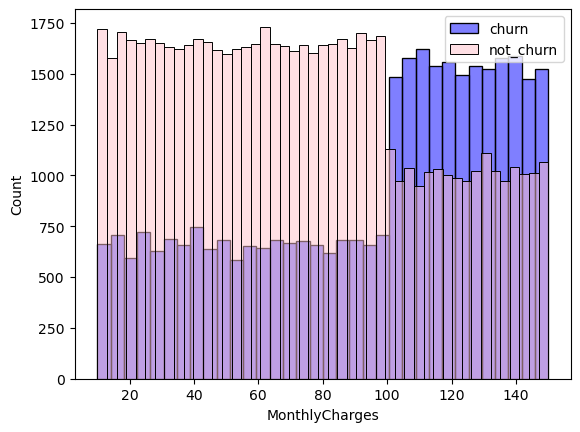

In [10]:
sns.histplot(churn, color="blue", alpha=0.5, label="churn")
sns.histplot(not_churn, color="pink", alpha=0.5, label="not_churn")
plt.legend()
plt.show()

In [11]:
from scipy .stats import ttest_ind

In [12]:
t_stat, p_value = ttest_ind(churn, not_churn, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 80.53122673583636
P-value: 0.0


In [13]:
alpha=0.05 #Assume
if p_value <= alpha:
    print("Reject H0: Monthly Charges significantly affect customer churn.")
else:
    print("Fail to Reject H0: No significant difference in Monthly Charges.")

Reject H0: Monthly Charges significantly affect customer churn.


In [14]:
churn_customer=df[df["Churn"]=="Yes"]

In [15]:
churn_customer.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
5,6,25,Female,29,111.55,Month-to-month,Credit card,3167.13,Yes
7,8,38,Male,11,96.63,Month-to-month,Bank transfer,1093.32,Yes
8,9,56,Male,43,74.06,Month-to-month,Mailed check,3230.58,Yes
13,14,28,Female,17,121.38,Month-to-month,Mailed check,2061.90,Yes


In [16]:
churn_count = churn_customer.shape[0]
total_customers = df.shape[0]

churn_rate = churn_count / total_customers * 100
churn_rate


33.144

In [17]:
total_revenue=df["TotalCharges"].sum().round(0)
churn_revanue=churn_customer["TotalCharges"].sum().round(0)
remaining_revanue=total_revenue-churn_revanue
print(f"total revenue:{total_revenue}")
print(f"churn revanue: {churn_revanue}")
print(f"remaining revanue: {remaining_revanue}")

total revenue:292614026.0
churn revanue: 99666316.0
remaining revanue: 192947710.0


In [18]:
print(f"total percenatge of churn revenue %:{((churn_revanue/total_revenue)*100).round(2)}")

total percenatge of churn revenue %:34.06


### Insights
- 1/3 Customers are churnning and Also 1/3 of Total revenue also churnning
- High monthly bill affect negativaly to revenue of company
### Recommend
- Offer to churn customers some low balance recharge or extra data

In [19]:
churn_customer["TotalCharges"].quantile(0.9)

np.float64(7188.312000000001)

- A small group (top 10%) of churned customers contributes disproportionately high revenue loss.

In [20]:
high_value_churn=churn_customer[churn_customer["TotalCharges"]>7188]
high_value_churn["TotalCharges"].sum()

np.float64(27739178.04)

In [21]:
(high_value_churn["TotalCharges"].sum()/churn_revanue)*100

np.float64(27.83204913483508)

- Customer churn is highly concentrated. The top 10% of churned customers account for nearly 28% of total churn revenue, indicating that revenue loss is driven by a small group of high-value customers rather than the overall customer base.

## Hypotheses test
### Objective
- How  does contract type affect churn?
### Hypotheses
- Null Hypotheses (Ho)- Contract Type is independent from churn
- Alternate Hypothese(H1)-Contract Type is related to churn

In [22]:
from scipy.stats import chi2_contingency

In [23]:
table=pd.crosstab(df["Contract"],df["Churn"])
chi2,p_value,dof,expected=chi2_contingency(table)
print("chi_squar :" , chi2)
print("p_value :" , p_value)

chi_squar : 9889.981708220985
p_value : 0.0


In [24]:
if p_value< 0.05:
    print(" reject Null Hypothesis(Ho):Contract Type is related to churn" )
else:
     print(" fail to reject Null Hypothesis(Ho): Contract Type is independent from churn")


 reject Null Hypothesis(Ho):Contract Type is related to churn


In [25]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No


In [26]:
result = df.groupby(["Contract", "Churn"]).agg({
    "MonthlyCharges": "mean",
    "TotalCharges": "sum"
}).reset_index()

print(result)

         Contract Churn  MonthlyCharges  TotalCharges
0  Month-to-month    No       71.057580   84556307.02
1  Month-to-month   Yes       90.240170   76266848.13
2        One year    No       74.323901   60858450.49
3        One year   Yes      108.593954   13188909.15
4        Two year    No       74.144425   47532952.33
5        Two year   Yes      107.794549   10210558.45


 ## Insigths
- Who is churnning ,they are paying more then who is not churnning, defferece between then is reasonable
### Recommendation
- Make Monthly charge Nearly Equal for all, give tthem some extra benefits

- Majority of high-value churn customers are on Month-to-Month contracts

- Long-term customers with high lifetime value still leave when there is no contract lock-in

In [27]:
high_value_churn["Contract"].value_counts(normalize=True) * 100



Contract
Month-to-month    70.325694
One year          16.827503
Two year          12.846803
Name: proportion, dtype: float64

In [28]:
df["Tenure"].value_counts()

Tenure
56    1480
25    1461
50    1454
22    1444
37    1442
      ... 
58    1328
55    1325
4     1314
57    1297
31    1281
Name: count, Length: 72, dtype: int64

## Hypotheses test
### Objective
- How does Tenure affect Churn?
### Hypotheses
- Null Hypotheses (Ho)- Tenure is independent from churn
- Alternate Hypothese(H1)- Tenure is Related to churn

- I Assume Tenure as categorical column because it has certain values

In [29]:
table=pd.crosstab(df["Tenure"],df["Churn"])
chi2,p_value,dof,expected=chi2_contingency(table)
print("chi_squar :" , chi2)
print("p_value :" , p_value)

chi_squar : 9608.37187004935
p_value : 0.0


In [30]:
if p_value< 0.05:
    print(" reject Null Hypothesis(Ho): Tenure is Related to churn")
else:
     print(" fail to reject Null Hypothesis(Ho): enure is independent from churn")


 reject Null Hypothesis(Ho): Tenure is Related to churn


In [31]:
result1 = df.groupby(["Tenure", "Churn"]).agg({
    "MonthlyCharges": "mean",
    "TotalCharges": "sum"
}).reset_index()

print(result1)

     Tenure Churn  MonthlyCharges  TotalCharges
0         1    No       66.075393      30852.32
1         1   Yes       84.410976      82134.36
2         2    No       67.100890      64667.74
3         2   Yes       86.066047     160962.78
4         3    No       65.300090      87009.05
..      ...   ...             ...           ...
139      70   Yes      102.355616    2615827.55
140      71    No       74.953990    5430197.18
141      71   Yes       98.803197    2569396.58
142      72    No       74.201011    5654007.07
143      72   Yes       97.829635    2704927.38

[144 rows x 4 columns]


### Insights
- It als show that churn customers pay more according to tenure so focus on it

In [32]:
from sqlalchemy import create_engine


user = 'root'
password = 'vishal**99'
host = 'localhost'  
port = 3306
database = 'telecome'


engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}')

In [33]:
df.to_sql("telecom_churn", engine, if_exists="replace", index=False)

print("Data uploaded successfully!")

Data uploaded successfully!
